# AvgGRM-diversity: greedy versus binary quadratic optimization

This notebook compares three ways of choosing a size-$k$ training subset that maximizes the AvgGRM-diversity objective: the **greedy** rule, an **exact convex MIQP** (Gurobi), and a **GA+SA metaheuristic**.

The exact MIQP certifies the true optimum, but only for small candidate sets — it is NP-hard and certified solve time grows steeply with $n$. It therefore runs only when `N_CANDIDATES` is small (controlled by `RUN_MIQP`), where it serves to validate that GA+SA reaches the optimum. For large candidate sets (e.g. $n = 1000$, $k = 300$) the MIQP is skipped and GA+SA versus greedy is the comparison.

For each repeat, the notebook samples a fixed number of source candidates, runs the applicable methods for several values of $k$ and $\lambda_{\mathrm{div}}$, and reports objective values, overlap, Jaccard similarity, and timing.

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadr
import gurobipy as gp
from gurobipy import GRB

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_ROOT

WindowsPath('c:/Users/Simen/OneDrive - NTNU/FYSMAT/INDMAT/MASTER/Master_thesis')

## Configuration

`N_CANDIDATES` and `K_VALUES` set the problem size. The exact MIQP is NP-hard, so it runs only for small candidate sets: `RUN_MIQP` below enables it automatically when `N_CANDIDATES` $\le 70$ and skips it otherwise. At the default large setting (`N_CANDIDATES = 1000`, `k = 300`) the MIQP is skipped and the notebook compares GA+SA against greedy; set `N_CANDIDATES` to a small value to also get the certified MIQP optimum.

In [2]:
NPZ_PATH = PROJECT_ROOT / "Data" / "npz" / "snp_body_mass_ALL.npz"
GRM_RDS_PATH = PROJECT_ROOT / "Data" / "GRM" / "GRM_vanraden.rds"

MIN_COUNT = 20

# Use either a consecutive island code, e.g. 9, or set TARGET_ISLAND_LABEL to an original locality label such as "35".
TARGET_ISLAND_CODE = 9
TARGET_ISLAND_LABEL = None

# Larger experiment: n = 1800, k = 600, six lambda values, five repeats per
# lambda. Per-setting cost at this size is roughly 3.5x what it was at
# (1000, 300), so we hold to 24 settings to keep the total wall time below
# one hour (estimated 45-55 minutes plus ~1 minute data load). Bumping
# N_REPEATS to 5 or 6 tightens the per-lambda standard errors but pushes
# closer to the budget; either is a one-line change.
N_CANDIDATES = 1800
K_VALUES = [600]
LAMBDA_DIVS = [0.1, 0.25, 0.5, 1.0, 1.5]
N_REPEATS = 5

INCLUDE_DIAGONAL = True
SEED = 20260520

# The exact MIQP only certifies for small candidate sets (certified solve time
# grows steeply with N_CANDIDATES and hits a wall around n = 70-80). It runs
# automatically when N_CANDIDATES is small and is skipped otherwise; in the
# large regime GA+SA versus greedy is the comparison. Override RUN_MIQP
# manually if needed.
RUN_MIQP = N_CANDIDATES <= 70

# Gurobi stops as soon as either the relative or the absolute MIP gap target
# is met. If the time limit is reached first, the BQP column holds the best
# incumbent found rather than a certified optimum.
MIQP_TIME_LIMIT_SECONDS = 600
MIQP_REL_GAP = 1e-3
MIQP_ABS_GAP = 1e-5
LOG_PROGRESS = True
PROGRESS_EVERY = 1

# Prints the full Gurobi branch-and-bound log during each MIQP solve.
MIQP_SOLVER_LOG = False

## Load only what the comparison needs

The comparison uses IDs, locality, and the Van Raden GRM. It does not load the full SNP matrix.

In [3]:
def load_ids_locality_grm(npz_path: Path, grm_rds_path: Path, min_count: int = 20):
    with np.load(npz_path, allow_pickle=False) as data:
        ids = np.asarray(data["ids"]).astype(str)
        locality = np.asarray(data["locality"]).astype(str).ravel()

    if ids.shape[0] != locality.shape[0]:
        raise ValueError("ids and locality have different lengths")

    grm_res = pyreadr.read_r(str(grm_rds_path))
    grm_df = next(iter(grm_res.values()))
    grm_df.index = grm_df.index.astype(str)
    grm_df.columns = grm_df.columns.astype(str)

    ids_in = np.array([sample_id for sample_id in ids if sample_id in grm_df.index], dtype=str)
    if ids_in.size == 0:
        raise ValueError("No overlapping IDs between NPZ and GRM")

    if ids_in.size != ids.size or not np.array_equal(ids_in, ids):
        pos = {sample_id: i for i, sample_id in enumerate(ids)}
        keep = np.array([pos[sample_id] for sample_id in ids_in], dtype=int)
        ids = ids[keep]
        locality = locality[keep]

    grm_df = grm_df.loc[ids, ids]

    # Match src.data.load_data: merge Ranes (68) into Lauvoya (67), then drop islands below min_count.
    locality = np.where(locality == "68", "67", locality)
    labels, counts = np.unique(locality, return_counts=True)
    keep_labels = set(labels[counts >= min_count])
    keep = np.array([label in keep_labels for label in locality], dtype=bool)

    ids = ids[keep]
    locality = locality[keep]
    grm_df = grm_df.loc[ids, ids]

    labels = np.array(sorted(np.unique(locality), key=lambda x: int(x)), dtype=str)
    label_to_code = {label: code for code, label in enumerate(labels)}
    code_to_label = {code: label for label, code in label_to_code.items()}
    locality_codes = np.array([label_to_code[label] for label in locality], dtype=int)

    return grm_df.to_numpy(dtype=float), ids, locality_codes, code_to_label


grm, ids, locality, code_to_label = load_ids_locality_grm(NPZ_PATH, GRM_RDS_PATH, MIN_COUNT)
counts = pd.Series(locality).value_counts().sort_index().rename_axis("island_code").reset_index(name="n")
counts["island_label"] = counts["island_code"].map(code_to_label)
display(counts)
print(f"Loaded GRM with shape {grm.shape}")

,island_code,n,island_label
0,0,119,20
1,1,92,22
2,2,292,23
3,3,194,24
4,4,558,26
5,5,1078,27
6,6,356,28
7,7,259,33
8,8,158,34
9,9,166,35


Loaded GRM with shape (5697, 5697)


In [4]:
if TARGET_ISLAND_LABEL is not None:
    label_to_code = {label: code for code, label in code_to_label.items()}
    target_code = int(label_to_code[str(TARGET_ISLAND_LABEL)])
else:
    target_code = int(TARGET_ISLAND_CODE)

target_idx = np.flatnonzero(locality == target_code)
source_idx_all = np.flatnonzero(locality != target_code)

if target_idx.size == 0:
    raise ValueError(f"No samples found for target island code {target_code}")
if source_idx_all.size < N_CANDIDATES:
    raise ValueError(f"Only {source_idx_all.size} source candidates available, fewer than N_CANDIDATES={N_CANDIDATES}")

print(f"Target island code: {target_code}, label: {code_to_label[target_code]}")
print(f"Target samples: {target_idx.size}")
print(f"Source candidates before subsampling: {source_idx_all.size}")

Target island code: 9, label: 35
Target samples: 166
Source candidates before subsampling: 5531


## Objective and greedy selection

In [5]:
def q_value(selected, avg_grm_to_target, train_train_grm, lambda_div, include_diagonal=True):
    selected = np.asarray(selected, dtype=int)
    if selected.size == 0:
        return np.nan

    target_term = float(np.mean(avg_grm_to_target[selected]))
    block = train_train_grm[np.ix_(selected, selected)]
    if include_diagonal or selected.size == 1:
        internal_term = float(np.mean(block))
    else:
        internal_term = float((np.sum(block) - np.trace(block)) / (selected.size * (selected.size - 1)))
    return target_term - float(lambda_div) * internal_term


def subset_stats(selected, avg_grm_to_target, train_train_grm, lambda_div, include_diagonal=True):
    selected = np.asarray(selected, dtype=int)
    block = train_train_grm[np.ix_(selected, selected)]
    if include_diagonal or selected.size == 1:
        internal = float(np.mean(block))
    else:
        internal = float((np.sum(block) - np.trace(block)) / (selected.size * (selected.size - 1)))
    target = float(np.mean(avg_grm_to_target[selected]))
    return {
        "q": target - float(lambda_div) * internal,
        "avg_grm_to_target": target,
        "avg_internal_grm": internal,
    }


def greedy_avggrm_diversity(avg_grm_to_target, train_train_grm, k, lambda_div, include_diagonal=True):
    s = np.asarray(avg_grm_to_target, dtype=float)
    G = np.asarray(train_train_grm, dtype=float)
    n = s.size

    selected_mask = np.zeros(n, dtype=bool)
    relatedness_to_selected = np.zeros(n, dtype=float)
    diag = np.diag(G)
    target_sum = 0.0
    train_train_sum = 0.0
    order = []

    for step in range(int(k)):
        next_size = step + 1
        candidate_target_sum = target_sum + s
        candidate_avg_target = candidate_target_sum / next_size

        if include_diagonal:
            candidate_train_train_sum = train_train_sum + 2.0 * relatedness_to_selected + diag
            candidate_avg_train_train = candidate_train_train_sum / (next_size * next_size)
        else:
            candidate_train_train_sum = train_train_sum + 2.0 * relatedness_to_selected
            if next_size <= 1:
                candidate_avg_train_train = np.zeros(n, dtype=float)
            else:
                candidate_avg_train_train = candidate_train_train_sum / (next_size * (next_size - 1))

        candidate_q = candidate_avg_target - float(lambda_div) * candidate_avg_train_train
        candidate_q = np.where(selected_mask, -np.inf, candidate_q)
        best = int(np.argmax(candidate_q))

        order.append(best)
        selected_mask[best] = True
        target_sum = float(candidate_target_sum[best])
        train_train_sum = float(candidate_train_train_sum[best])
        relatedness_to_selected += G[:, best]

    return np.array(order, dtype=int)

## Binary quadratic optimization as a convex MIQP

For fixed $k$, the objective is maximized over binary variables $x_i \in \{0,1\}$ subject to the cardinality constraint $\sum_i x_i = k$:

$$\max_{x}\; \frac{1}{k}\sum_i s_i x_i \;-\; \frac{\lambda_{\mathrm{div}}}{k^2}\,x^\top G\,x$$

where $s$ is the average GRM from each candidate to the target island and $G$ is the candidate-by-candidate GRM block. The Van Raden GRM is positive semidefinite, so $x^\top G x$ is convex and this is a *convex* mixed-integer quadratic program (MIQP). Gurobi receives the quadratic objective directly — one binary variable per candidate, a single linear constraint, and no McCormick product variables. If $G$ is numerically indefinite it is ridge-shifted to $G + \varepsilon I$; since $x^\top(\varepsilon I)\,x = \varepsilon k$ is constant on the cardinality set, the optimal subset is unchanged. When Gurobi closes the gap, the result is the exact optimum for the subsampled candidate set.

In [6]:
def solve_avggrm_diversity_miqp(
    avg_grm_to_target,
    train_train_grm,
    k,
    lambda_div,
    include_diagonal=True,
    time_limit=600.0,
    mip_rel_gap=1e-3,
    mip_abs_gap=1e-5,
    warm_start=None,
    verbose=False,
    solver_log=False,
):
    """Exact convex MIQP for the AvgGRM-diversity objective, solved with Gurobi.

    The Van Raden GRM block is positive semidefinite, so maximizing Q is a
    concave-maximization (convex) MIQP. Gurobi receives the quadratic objective
    directly, with one binary variable per candidate and a single cardinality
    constraint -- no McCormick product variables. The GRM block is symmetrized
    and, if needed, ridge-shifted to be positive semidefinite; on the
    cardinality set sum(x) = k that shift only adds a constant, so the optimal
    subset is unchanged.

    Returns the selected local indices, a solver-info dict, and the wall time.
    """
    s = np.asarray(avg_grm_to_target, dtype=float).reshape(-1)
    G = np.asarray(train_train_grm, dtype=float)
    n = s.size
    k = int(k)
    if not (1 <= k <= n):
        raise ValueError("k must be between 1 and the number of candidates")

    # Symmetrize and ridge-shift to a positive-semidefinite matrix.
    G = 0.5 * (G + G.T)
    eig_min = float(np.linalg.eigvalsh(G)[0])
    ridge = max(0.0, 1e-6 - eig_min)
    G_psd = G + ridge * np.eye(n) if ridge > 0.0 else G

    if verbose:
        print(
            f"MIQP: n={n}, k={k}, lambda={lambda_div:g}, binary_vars={n}, "
            f"GRM eig_min={eig_min:.3e}, ridge={ridge:.1e}, time_limit={time_limit:g}s",
            flush=True,
        )

    model = gp.Model("avggrm_diversity")
    model.Params.OutputFlag = 1 if solver_log else 0
    model.Params.TimeLimit = float(time_limit)
    model.Params.MIPGap = float(mip_rel_gap)
    model.Params.MIPGapAbs = float(mip_abs_gap)

    x = model.addMVar(n, vtype=GRB.BINARY, name="x")
    model.addConstr(x.sum() == k, name="cardinality")

    if warm_start is not None:
        warm_vec = np.zeros(n, dtype=float)
        warm_vec[np.asarray(warm_start, dtype=int)] = 1.0
        x.Start = warm_vec

    # Q = (1/k) s'x - (lambda/k^2) x'Gx                              if include_diagonal
    # Q = (1/k) s'x - (lambda/(k(k-1))) (x'Gx - sum_i G_ii x_i)      otherwise
    # x'Gx is convex, so for a maximization the objective is concave (a convex MIQP).
    linear = (s / k) @ x
    quad = x @ G_psd @ x
    if include_diagonal:
        model.setObjective(linear - (lambda_div / (k * k)) * quad, GRB.MAXIMIZE)
    else:
        diag_lin = np.diag(G_psd) @ x
        model.setObjective(
            linear - (lambda_div / (k * (k - 1))) * (quad - diag_lin), GRB.MAXIMIZE
        )

    start = time.perf_counter()
    model.optimize()
    elapsed = time.perf_counter() - start

    if model.SolCount == 0:
        info = {
            "success": False, "status": int(model.Status), "status_name": "no_solution",
            "certified": False, "mip_gap": np.nan, "abs_gap": np.nan, "obj_bound": np.nan,
        }
        return np.array([], dtype=int), info, elapsed

    x_val = np.asarray(x.X)
    selected = np.flatnonzero(x_val > 0.5)
    if selected.size != k:
        selected = np.argsort(-x_val)[:k]

    status = int(model.Status)
    status_name = {GRB.OPTIMAL: "optimal", GRB.TIME_LIMIT: "time_limit"}.get(status, f"status_{status}")
    obj_val = float(model.ObjVal)
    obj_bound = float(model.ObjBound)
    info = {
        "success": True,
        "status": status,
        "status_name": status_name,
        "certified": status == GRB.OPTIMAL,
        "mip_gap": float(model.MIPGap),
        "abs_gap": abs(obj_bound - obj_val),
        "obj_bound": obj_bound,
    }
    return np.array(selected, dtype=int), info, elapsed

## Run repeated subsampling comparison

In [7]:
if not RUN_MIQP:
    # Exact certification is impractical at this candidate-set size; skip the
    # MIQP and let the GA+SA section compare against greedy only.
    results_df = None
    selected_sets = None
    print(
        f"MIQP section skipped: N_CANDIDATES={N_CANDIDATES} is too large for exact "
        f"certification (RUN_MIQP is False).",
        flush=True,
    )
    print("GA+SA versus greedy will be the comparison; see the section below.", flush=True)
else:
    rng = np.random.default_rng(SEED)
    rows = []
    selected_sets = []

    settings = [(repeat, lambda_div, k) for repeat in range(N_REPEATS) for lambda_div in LAMBDA_DIVS for k in K_VALUES]
    total_jobs = len(settings)
    job_idx = 0
    run_start = time.perf_counter()

    print(
        f"Running {total_jobs} MIQP comparisons: "
        f"N_CANDIDATES={N_CANDIDATES}, repeats={N_REPEATS}, "
        f"k={K_VALUES}, lambda={LAMBDA_DIVS}, "
        f"time_limit={MIQP_TIME_LIMIT_SECONDS}s, rel_gap={MIQP_REL_GAP}, abs_gap={MIQP_ABS_GAP}",
        flush=True,
    )

    for repeat in range(N_REPEATS):
        sampled_global_idx = rng.choice(source_idx_all, size=N_CANDIDATES, replace=False)
        sample_ids = ids[sampled_global_idx]

        avg_grm_to_target = grm[np.ix_(sampled_global_idx, target_idx)].mean(axis=1)
        train_train_grm = grm[np.ix_(sampled_global_idx, sampled_global_idx)]

        for lambda_div in LAMBDA_DIVS:
            for k in K_VALUES:
                job_idx += 1
                if LOG_PROGRESS and (job_idx == 1 or job_idx % PROGRESS_EVERY == 0):
                    elapsed = time.perf_counter() - run_start
                    print(
                        f"[{job_idx:>3}/{total_jobs}] repeat={repeat}, lambda={lambda_div:g}, k={k} "
                        f"starting after {elapsed:.1f}s",
                        flush=True,
                    )

                g_t0 = time.perf_counter()
                greedy_sel = greedy_avggrm_diversity(
                    avg_grm_to_target,
                    train_train_grm,
                    k=k,
                    lambda_div=lambda_div,
                    include_diagonal=INCLUDE_DIAGONAL,
                )
                greedy_time = time.perf_counter() - g_t0
                # Warm-start the MIQP with the greedy solution to prune the search tree.
                bqp_sel, solver_info, solve_time = solve_avggrm_diversity_miqp(
                    avg_grm_to_target,
                    train_train_grm,
                    k=k,
                    lambda_div=lambda_div,
                    include_diagonal=INCLUDE_DIAGONAL,
                    time_limit=MIQP_TIME_LIMIT_SECONDS,
                    mip_rel_gap=MIQP_REL_GAP,
                    mip_abs_gap=MIQP_ABS_GAP,
                    warm_start=greedy_sel,
                    verbose=LOG_PROGRESS,
                    solver_log=MIQP_SOLVER_LOG,
                )

                greedy_stats = subset_stats(greedy_sel, avg_grm_to_target, train_train_grm, lambda_div, INCLUDE_DIAGONAL)
                bqp_stats = subset_stats(bqp_sel, avg_grm_to_target, train_train_grm, lambda_div, INCLUDE_DIAGONAL)

                greedy_set = set(map(int, greedy_sel))
                bqp_set = set(map(int, bqp_sel))
                overlap = len(greedy_set & bqp_set)
                union = len(greedy_set | bqp_set)
                q_diff = bqp_stats["q"] - greedy_stats["q"]
                solver_mip_gap = solver_info["mip_gap"]
                bqp_certified = bool(solver_info["certified"])

                rows.append({
                    "repeat": repeat,
                    "target_code": target_code,
                    "target_label": code_to_label[target_code],
                    "n_candidates": N_CANDIDATES,
                    "k": int(k),
                    "lambda_div": float(lambda_div),
                    "q_greedy": greedy_stats["q"],
                    "q_bqp": bqp_stats["q"],
                    "q_diff_bqp_minus_greedy": q_diff,
                    "q_abs_diff": abs(q_diff),
                    "q_rel_diff": q_diff / max(abs(bqp_stats["q"]), 1e-12),
                    "bqp_better_than_greedy": bool(q_diff > 1e-10),
                    "bqp_certified": bqp_certified,
                    "overlap_n": overlap,
                    "overlap_frac": overlap / float(k),
                    "jaccard": overlap / float(union) if union else np.nan,
                    "avg_target_greedy": greedy_stats["avg_grm_to_target"],
                    "avg_target_bqp": bqp_stats["avg_grm_to_target"],
                    "avg_internal_greedy": greedy_stats["avg_internal_grm"],
                    "avg_internal_bqp": bqp_stats["avg_internal_grm"],
                    "solver_success": bool(solver_info["success"]),
                    "solver_status": int(solver_info["status"]),
                    "solver_message": str(solver_info["status_name"]),
                    "solver_mip_gap": solver_mip_gap,
                    "solver_abs_gap": solver_info["abs_gap"],
                    "greedy_time_sec": greedy_time,
                    "solve_time_sec": solve_time,
                })

                if LOG_PROGRESS and (job_idx == 1 or job_idx % PROGRESS_EVERY == 0):
                    status = "certified" if bqp_certified else "incumbent"
                    elapsed = time.perf_counter() - run_start
                    print(
                        f"[{job_idx:>3}/{total_jobs}] done in {solve_time:.2f}s "
                        f"(greedy {greedy_time*1000:.1f} ms), "
                        f"status={solver_info['status_name']}, rel_gap={solver_mip_gap:.4g}, "
                        f"abs_gap={solver_info['abs_gap']:.4g}, {status}, "
                        f"q_diff={q_diff:.4g}, overlap={overlap}/{k}, elapsed={elapsed:.1f}s",
                        flush=True,
                    )

                selected_sets.append({
                    "repeat": repeat,
                    "k": int(k),
                    "lambda_div": float(lambda_div),
                    "sample_ids": sample_ids,
                    "greedy_local_idx": greedy_sel,
                    "bqp_local_idx": bqp_sel,
                    "greedy_ids": sample_ids[greedy_sel],
                    "bqp_ids": sample_ids[bqp_sel],
                })

    results_df = pd.DataFrame(rows)
    display(results_df.head())
    print(f"Finished {len(results_df)} comparisons in {time.perf_counter() - run_start:.1f}s")

MIQP section skipped: N_CANDIDATES=1800 is too large for exact certification (RUN_MIQP is False).
GA+SA versus greedy will be the comparison; see the section below.


## Summary tables

In [8]:
if RUN_MIQP:
    summary = (
        results_df
        .groupby(["lambda_div", "k"], as_index=False)
        .agg(
            n=("repeat", "count"),
            q_greedy_mean=("q_greedy", "mean"),
            q_bqp_mean=("q_bqp", "mean"),
            q_diff_mean=("q_diff_bqp_minus_greedy", "mean"),
            q_diff_sd=("q_diff_bqp_minus_greedy", "std"),
            q_diff_max=("q_diff_bqp_minus_greedy", "max"),
            overlap_frac_mean=("overlap_frac", "mean"),
            overlap_frac_sd=("overlap_frac", "std"),
            jaccard_mean=("jaccard", "mean"),
            solve_time_mean=("solve_time_sec", "mean"),
            solver_success_rate=("solver_success", "mean"),
            bqp_certified_rate=("bqp_certified", "mean"),
        )
    )
    display(summary)
else:
    print("MIQP section skipped (N_CANDIDATES too large for exact solving).")

MIQP section skipped (N_CANDIDATES too large for exact solving).


In [9]:
if RUN_MIQP:
    failed = results_df.loc[
        ~results_df["bqp_certified"],
        ["repeat", "lambda_div", "k", "solver_status", "solver_message", "solver_mip_gap", "solver_abs_gap", "solve_time_sec", "q_diff_bqp_minus_greedy"],
    ]
    display(failed)

    if failed.empty:
        print("All MIQP solves were certified as optimal within the requested gap.")
    else:
        print("Some MIQP solves hit the time limit; those BQP results are best incumbents, not certified optima.")
else:
    print("MIQP section skipped.")

MIQP section skipped.


## Plots

In [10]:
if RUN_MIQP:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for lambda_div, group in results_df.groupby("lambda_div"):
        axes[0].scatter(group["q_bqp"], group["q_greedy"], label=f"lambda={lambda_div:g}", alpha=0.75)
    lims = [min(results_df["q_bqp"].min(), results_df["q_greedy"].min()), max(results_df["q_bqp"].max(), results_df["q_greedy"].max())]
    axes[0].plot(lims, lims, color="black", linewidth=1)
    axes[0].set_xlabel("BQP Q")
    axes[0].set_ylabel("Greedy Q")
    axes[0].set_title("Objective comparison")
    axes[0].legend(fontsize=8)

    results_df.boxplot(column="q_diff_bqp_minus_greedy", by=["lambda_div", "k"], ax=axes[1], rot=45)
    axes[1].set_title("BQP incumbent - greedy Q")
    axes[1].set_xlabel("(lambda, k)")
    axes[1].set_ylabel("Q difference")

    results_df.boxplot(column="jaccard", by=["lambda_div", "k"], ax=axes[2], rot=45)
    axes[2].set_title("Selected-set Jaccard")
    axes[2].set_xlabel("(lambda, k)")
    axes[2].set_ylabel("Jaccard similarity")

    fig.suptitle("")
    fig.tight_layout()
    plt.show()
else:
    print("MIQP section skipped; no MIQP-vs-greedy plots.")

MIQP section skipped; no MIQP-vs-greedy plots.


## Inspect the largest disagreements

In [11]:
if RUN_MIQP:
    worst = results_df.sort_values(["q_diff_bqp_minus_greedy", "jaccard"], ascending=[False, True]).head(10)
    display(worst[[
        "repeat", "lambda_div", "k", "q_greedy", "q_bqp", "q_diff_bqp_minus_greedy", "overlap_frac", "jaccard",
        "avg_target_greedy", "avg_target_bqp", "avg_internal_greedy", "avg_internal_bqp", "solver_success", "solver_mip_gap"
    ]])

    if not worst.empty:
        row = worst.iloc[0]
        match = next(
            item for item in selected_sets
            if item["repeat"] == row["repeat"] and item["k"] == row["k"] and item["lambda_div"] == row["lambda_div"]
        )
        greedy_only = sorted(set(match["greedy_ids"]) - set(match["bqp_ids"]))
        bqp_only = sorted(set(match["bqp_ids"]) - set(match["greedy_ids"]))
        print("Worst case IDs selected only by greedy:")
        print(greedy_only)
        print("Worst case IDs selected only by BQP:")
        print(bqp_only)
else:
    print("MIQP section skipped.")

MIQP section skipped.


## Genetic algorithm with simulated annealing

The convex MIQP above is exact, but it is still an NP-hard cardinality-constrained problem: certified solve time grows steeply with the candidate-set size, and beyond roughly $n = 80$ the hardest $\lambda_{\mathrm{div}}$ settings no longer close the gap within a practical time budget.

This section optimizes the *same* objective with the metaheuristic used by Fernandez-Gonzalez et al. (2023), built around TrainSel (Akdemir et al. 2021): a **genetic algorithm** for global search combined with **simulated annealing** for local refinement.

- each individual is a size-$k$ subset of the candidate pool,
- the population evolves through tournament selection, subset crossover (the child keeps the shared elements and fills the rest from the parents' symmetric difference), and swap mutation, with elitism preserving the best individuals,
- every offspring is refined by a few simulated-annealing swap steps that accept a worsening swap with probability $\exp(\Delta Q / T)$, with $T$ cooled geometrically across generations,
- a best-improvement local search periodically polishes the incumbent and runs once more at the end, so the returned subset is at least a one-swap local optimum,
- one individual is seeded with the greedy solution as a warm start, so GA+SA can never return a worse subset than greedy.

The objective is evaluated **incrementally**. Each subset carries a running vector $\mathrm{rel}[c] = \sum_{j \in S} G_{c,j}$; a single swap is then scored in $O(1)$ and committed in $O(n)$, instead of the $O(k^2)$ cost of recomputing $Q$ from scratch. Best-improvement local search becomes one vectorized $O(k\cdot n)$ pass over all candidate swaps. This is what makes the method practical for large $k$ (e.g. $n = 1000$, $k = 300$).

GA+SA does not certify optimality, but it returns a near-optimal subset in seconds and its cost grows gently with the candidate pool size, so it stays usable well past the size where exact certification becomes impractical. The run cell below works whether the MIQP section above was executed or not: when MIQP results are present they are compared against on the same subsamples, otherwise GA+SA is compared against greedy alone.

In [12]:
def optimize_avggrm_diversity_ga_sa(
    avg_grm_to_target,
    train_train_grm,
    k,
    lambda_div,
    include_diagonal=True,
    pop_size=80,
    n_generations=250,
    sa_steps_per_gen=12,
    tournament_size=3,
    elite_frac=0.1,
    mutation_rate=0.6,
    mutation_swaps=2,
    polish_every=40,
    seed_solution=None,
    rng=None,
):
    """Genetic algorithm with simulated-annealing refinement for AvgGRM-diversity.

    Maximizes the same Q as ``q_value`` by evolving a population of size-``k``
    subsets, mirroring the TrainSel strategy of Fernandez-Gonzalez et al.
    (2023): a genetic algorithm explores globally while simulated-annealing
    swap steps refine every offspring and a best-improvement local search
    polishes the incumbent.

    The objective is evaluated incrementally. Each subset carries a state with
    a running vector ``rel[c] = sum_{j in S} G[c, j]``; a swap (drop one
    member, add one non-member) is then scored in O(1) and committed in O(n),
    instead of the O(k^2) cost of recomputing Q from scratch. This keeps the
    search practical at large k (e.g. n = 1000, k = 300).

    Returns the best subset (sorted local indices), its Q value, and the
    per-generation history of the best Q.
    """
    if rng is None:
        rng = np.random.default_rng()

    s = np.asarray(avg_grm_to_target, dtype=float).reshape(-1)
    G = np.asarray(train_train_grm, dtype=float)
    n = s.size
    k = int(k)
    if not (1 <= k <= n):
        raise ValueError("k must be between 1 and the number of candidates")
    diag_G = np.ascontiguousarray(np.diag(G), dtype=float)

    # Q = tsum / k - qcoef * quad, where quad excludes the diagonal when
    # include_diagonal is False (matching q_value).
    if include_diagonal:
        qcoef = lambda_div / (k * k)
        drop_diag = False
    else:
        qcoef = lambda_div / (k * (k - 1)) if k > 1 else 0.0
        drop_diag = True

    # --- incremental subset state -----------------------------------------
    # rel[c] = sum_{j in S} G[c, j]; qsum = sum_{i, j in S} G_ij (with diagonal).
    def make_state(subset):
        members = np.asarray(subset, dtype=int).copy()
        in_mask = np.zeros(n, dtype=bool)
        in_mask[members] = True
        rel = G[:, members].sum(axis=1)
        return {
            "members": members,
            "in_mask": in_mask,
            "tsum": float(s[members].sum()),
            "qsum": float(rel[members].sum()),
            "rel": rel,
        }

    def state_q(st):
        quad = st["qsum"]
        if drop_diag:
            quad = quad - float(diag_G[st["members"]].sum())
        return st["tsum"] / k - qcoef * quad

    def swap_delta(st, out_pos, in_elem):
        # Change in Q for dropping members[out_pos] and adding in_elem.
        out_elem = st["members"][out_pos]
        rel = st["rel"]
        d_quad = (-2.0 * rel[out_elem] + diag_G[out_elem]
                  + 2.0 * (rel[in_elem] - G[in_elem, out_elem]) + diag_G[in_elem])
        d_q = (s[in_elem] - s[out_elem]) / k - qcoef * d_quad
        if drop_diag:
            d_q += qcoef * (diag_G[in_elem] - diag_G[out_elem])
        return d_q

    def apply_swap(st, out_pos, in_elem):
        out_elem = st["members"][out_pos]
        rel = st["rel"]
        d_quad = (-2.0 * rel[out_elem] + diag_G[out_elem]
                  + 2.0 * (rel[in_elem] - G[in_elem, out_elem]) + diag_G[in_elem])
        st["qsum"] += d_quad
        st["tsum"] += s[in_elem] - s[out_elem]
        rel += G[:, in_elem] - G[:, out_elem]
        st["in_mask"][out_elem] = False
        st["in_mask"][in_elem] = True
        st["members"][out_pos] = in_elem

    def fitness(subset):
        return state_q(make_state(subset))

    def random_subset():
        return rng.choice(n, size=k, replace=False)

    def draw_non_member(in_mask):
        # Rejection sampling for a uniform non-member; k < n so this terminates fast.
        while True:
            cand = int(rng.integers(n))
            if not in_mask[cand]:
                return cand

    def anneal(subset, temp):
        st = make_state(subset)
        if k < n:
            for _ in range(sa_steps_per_gen):
                out_pos = int(rng.integers(k))
                in_elem = draw_non_member(st["in_mask"])
                delta = swap_delta(st, out_pos, in_elem)
                if delta >= 0.0 or rng.random() < np.exp(delta / temp):
                    apply_swap(st, out_pos, in_elem)
        return st["members"].copy(), state_q(st)

    def local_search(subset):
        # Best-improvement single-swap hill climbing, vectorized over all
        # (out_pos, in_elem) pairs in one O(k*n) pass.
        st = make_state(subset)
        while k < n:
            members = st["members"]
            rel = st["rel"]
            a = -2.0 * rel[members] + diag_G[members]
            b = 2.0 * rel + diag_G
            d_quad = a[:, None] + b[None, :] - 2.0 * G[members, :]
            d_q = (s[None, :] - s[members][:, None]) / k - qcoef * d_quad
            if drop_diag:
                d_q += qcoef * (diag_G[None, :] - diag_G[members][:, None])
            d_q[:, st["in_mask"]] = -np.inf
            flat = int(np.argmax(d_q))
            out_pos, in_elem = flat // n, flat % n
            if d_q[out_pos, in_elem] <= 1e-12:
                break
            apply_swap(st, out_pos, in_elem)
        return st["members"].copy(), state_q(st)

    # --- annealing temperature schedule -----------------------------------
    # Calibrate to the scale of single-swap |delta Q| seen from random subsets,
    # so early SA steps can genuinely escape local optima.
    deltas = []
    if k < n:
        for _ in range(25):
            probe = make_state(random_subset())
            for _ in range(12):
                out_pos = int(rng.integers(k))
                in_elem = draw_non_member(probe["in_mask"])
                deltas.append(abs(swap_delta(probe, out_pos, in_elem)))
    positive = [d for d in deltas if d > 0]
    scale = float(np.mean(positive)) if positive else 1e-6
    temps = np.geomspace(scale, scale * 1e-3, num=max(n_generations, 1))

    # --- initial population ------------------------------------------------
    population = [random_subset() for _ in range(pop_size)]
    if seed_solution is not None:
        population[0] = np.asarray(seed_solution, dtype=int).copy()
    fitness_values = np.array([fitness(ind) for ind in population], dtype=float)

    # --- genetic operators -------------------------------------------------
    def tournament():
        contenders = rng.choice(pop_size, size=min(tournament_size, pop_size), replace=False)
        return population[contenders[int(np.argmax(fitness_values[contenders]))]]

    def crossover(parent_a, parent_b):
        set_a, set_b = set(parent_a.tolist()), set(parent_b.tolist())
        common = np.array(sorted(set_a & set_b), dtype=int)
        pool = np.array(sorted(set_a ^ set_b), dtype=int)
        rng.shuffle(pool)
        return np.concatenate([common, pool[: k - common.size]])

    def mutate(individual):
        if k == n:
            return individual
        child = individual.copy()
        in_mask = np.zeros(n, dtype=bool)
        in_mask[child] = True
        not_in = np.flatnonzero(~in_mask)
        n_swap = min(mutation_swaps, k, not_in.size)
        out_pos = rng.choice(k, size=n_swap, replace=False)
        child[out_pos] = rng.choice(not_in, size=n_swap, replace=False)
        return child

    # --- evolution loop ----------------------------------------------------
    best = population[int(np.argmax(fitness_values))].copy()
    best_fit = float(np.max(fitness_values))
    history = [best_fit]
    elite_count = max(1, int(round(elite_frac * pop_size)))

    for gen in range(n_generations):
        temp = float(temps[gen])
        order = np.argsort(fitness_values)[::-1]
        new_population = [population[i].copy() for i in order[:elite_count]]
        new_fitness = [float(fitness_values[i]) for i in order[:elite_count]]
        while len(new_population) < pop_size:
            child = crossover(tournament(), tournament())
            if rng.random() < mutation_rate:
                child = mutate(child)
            child, child_fit = anneal(child, temp)
            new_population.append(child)
            new_fitness.append(child_fit)
        population = new_population
        fitness_values = np.array(new_fitness, dtype=float)

        gen_best = int(np.argmax(fitness_values))
        if fitness_values[gen_best] > best_fit:
            best_fit = float(fitness_values[gen_best])
            best = population[gen_best].copy()

        # Memetic polish: drive the incumbent to a local optimum and feed it
        # back into the population so crossover can spread its good elements.
        if polish_every and (gen + 1) % polish_every == 0:
            polished, polished_fit = local_search(best)
            if polished_fit > best_fit:
                best_fit, best = polished_fit, polished.copy()
            worst = int(np.argmin(fitness_values))
            population[worst] = polished
            fitness_values[worst] = polished_fit

        history.append(best_fit)

    best, best_fit = local_search(best)
    history.append(best_fit)
    return np.sort(best), best_fit, np.array(history, dtype=float)

In [13]:
# GA+SA hyperparameters. Roughly mirrors the TrainSel settings in
# Fernandez-Gonzalez et al. (2023): a few hundred GA generations, each
# refined by a handful of simulated-annealing swap steps. Tuned upward from
# the small-experiment defaults (250 gens / 2-swap mutation / polish every 40)
# because the n = 1000, k = 300 run showed repeat-to-repeat variance in the
# gain at high lambda. GA_MUTATION_SWAPS is scaled with k so that mutation
# moves stay around 1.5-2% of the subset size (5 at k=300, 10 at k=600).
GA_POP_SIZE = 80
GA_GENERATIONS = 400
GA_SA_STEPS = 12
GA_TOURNAMENT = 3
GA_ELITE_FRAC = 0.1
GA_MUTATION_RATE = 0.7
GA_MUTATION_SWAPS = 10
GA_POLISH_EVERY = 25
GA_SEED_WITH_GREEDY = True

# Reuse the MIQP results if the section above ran; otherwise compare against greedy only.
_has_miqp = (
    globals().get("results_df") is not None
    and globals().get("selected_sets") is not None
)
if _has_miqp:
    bqp_lookup = {
        (int(d["repeat"]), int(d["k"]), float(d["lambda_div"])): np.asarray(d["bqp_local_idx"], dtype=int)
        for d in selected_sets
    }

# Same seed as the MIQP run, so the subsamples are identical and comparable.
sub_rng = np.random.default_rng(SEED)
ga_rows = []
ga_selected_sets = []
ga_run_start = time.perf_counter()

total_ga_jobs = N_REPEATS * len(LAMBDA_DIVS) * len(K_VALUES)
print(
    f"Running {total_ga_jobs} GA+SA optimizations: "
    f"N_CANDIDATES={N_CANDIDATES}, k={K_VALUES}, "
    f"pop={GA_POP_SIZE}, generations={GA_GENERATIONS}, sa_steps={GA_SA_STEPS}, "
    f"mutation_rate={GA_MUTATION_RATE}, mutation_swaps={GA_MUTATION_SWAPS}, "
    f"polish_every={GA_POLISH_EVERY}, "
    f"seed_with_greedy={GA_SEED_WITH_GREEDY}, miqp_results_available={_has_miqp}",
    flush=True,
)

for repeat in range(N_REPEATS):
    sampled_global_idx = sub_rng.choice(source_idx_all, size=N_CANDIDATES, replace=False)
    sample_ids = ids[sampled_global_idx]

    avg_grm_to_target = grm[np.ix_(sampled_global_idx, target_idx)].mean(axis=1)
    train_train_grm = grm[np.ix_(sampled_global_idx, sampled_global_idx)]

    for lambda_div in LAMBDA_DIVS:
        for k in K_VALUES:
            g_t0 = time.perf_counter()
            greedy_sel = greedy_avggrm_diversity(
                avg_grm_to_target,
                train_train_grm,
                k=k,
                lambda_div=lambda_div,
                include_diagonal=INCLUDE_DIAGONAL,
            )
            greedy_time = time.perf_counter() - g_t0

            # Deterministic per-setting RNG so the section is reproducible.
            ga_rng = np.random.default_rng([SEED, repeat, int(round(lambda_div * 1000)), int(k)])
            start = time.perf_counter()
            ga_sel, ga_fit, ga_history = optimize_avggrm_diversity_ga_sa(
                avg_grm_to_target,
                train_train_grm,
                k=k,
                lambda_div=lambda_div,
                include_diagonal=INCLUDE_DIAGONAL,
                pop_size=GA_POP_SIZE,
                n_generations=GA_GENERATIONS,
                sa_steps_per_gen=GA_SA_STEPS,
                tournament_size=GA_TOURNAMENT,
                elite_frac=GA_ELITE_FRAC,
                mutation_rate=GA_MUTATION_RATE,
                mutation_swaps=GA_MUTATION_SWAPS,
                polish_every=GA_POLISH_EVERY,
                seed_solution=greedy_sel if GA_SEED_WITH_GREEDY else None,
                rng=ga_rng,
            )
            ga_time = time.perf_counter() - start

            greedy_stats = subset_stats(greedy_sel, avg_grm_to_target, train_train_grm, lambda_div, INCLUDE_DIAGONAL)
            ga_stats = subset_stats(ga_sel, avg_grm_to_target, train_train_grm, lambda_div, INCLUDE_DIAGONAL)

            ga_set = set(map(int, ga_sel))
            greedy_set = set(map(int, greedy_sel))
            overlap_greedy = len(ga_set & greedy_set)
            union_greedy = len(ga_set | greedy_set)

            target_gain = ga_stats["avg_grm_to_target"] - greedy_stats["avg_grm_to_target"]
            internal_reduction = greedy_stats["avg_internal_grm"] - ga_stats["avg_internal_grm"]
            q_relative_gain = (ga_stats["q"] - greedy_stats["q"]) / max(abs(greedy_stats["q"]), 1e-12)

            row = {
                "repeat": repeat,
                "target_code": target_code,
                "target_label": code_to_label[target_code],
                "n_candidates": N_CANDIDATES,
                "k": int(k),
                "lambda_div": float(lambda_div),
                # objective values
                "q_greedy": greedy_stats["q"],
                "q_ga": ga_stats["q"],
                "q_ga_minus_greedy": ga_stats["q"] - greedy_stats["q"],
                "q_relative_gain": q_relative_gain,
                # objective decomposition
                "avg_target_greedy": greedy_stats["avg_grm_to_target"],
                "avg_target_ga": ga_stats["avg_grm_to_target"],
                "target_gain_ga_minus_greedy": target_gain,
                "avg_internal_greedy": greedy_stats["avg_internal_grm"],
                "avg_internal_ga": ga_stats["avg_internal_grm"],
                "internal_reduction_ga_vs_greedy": internal_reduction,
                # set overlap with greedy
                "ga_overlap_greedy": overlap_greedy,
                "ga_overlap_frac_greedy": overlap_greedy / float(k),
                "ga_jaccard_greedy": overlap_greedy / float(union_greedy) if union_greedy else np.nan,
                # timing
                "greedy_time_sec": greedy_time,
                "ga_time_sec": ga_time,
                "ga_time_per_generation_ms": 1000.0 * ga_time / max(GA_GENERATIONS, 1),
                "ga_generations": GA_GENERATIONS,
            }

            if _has_miqp:
                miqp_match = results_df[
                    (results_df["repeat"] == repeat)
                    & (results_df["lambda_div"] == lambda_div)
                    & (results_df["k"] == k)
                ]
                if not miqp_match.empty:
                    miqp_match = miqp_match.iloc[0]
                    q_bqp = float(miqp_match["q_bqp"])
                    bqp_sel = bqp_lookup.get((repeat, int(k), float(lambda_div)), np.array([], dtype=int))
                    bqp_set = set(map(int, bqp_sel))
                    overlap_bqp = len(ga_set & bqp_set)
                    union_bqp = len(ga_set | bqp_set)
                    overlap_greedy_bqp = len(greedy_set & bqp_set)
                    union_greedy_bqp = len(greedy_set | bqp_set)
                    row.update({
                        "q_bqp": q_bqp,
                        "q_bqp_minus_ga": q_bqp - ga_stats["q"],
                        "q_bqp_minus_greedy": q_bqp - greedy_stats["q"],
                        "ga_matches_bqp": bool(abs(q_bqp - ga_stats["q"]) <= 1e-3 * max(abs(q_bqp), 1e-12)),
                        "ga_overlap_bqp": overlap_bqp,
                        "ga_jaccard_bqp": overlap_bqp / float(union_bqp) if union_bqp else np.nan,
                        "greedy_overlap_bqp": overlap_greedy_bqp,
                        "greedy_jaccard_bqp": overlap_greedy_bqp / float(union_greedy_bqp) if union_greedy_bqp else np.nan,
                        "bqp_certified": bool(miqp_match["bqp_certified"]),
                        "miqp_time_sec": float(miqp_match["solve_time_sec"]),
                        "miqp_speedup_over_ga": float(miqp_match["solve_time_sec"]) / max(ga_time, 1e-9),
                    })

            ga_rows.append(row)
            ga_selected_sets.append({
                "repeat": repeat,
                "k": int(k),
                "lambda_div": float(lambda_div),
                "sample_ids": sample_ids,
                "ga_local_idx": ga_sel,
                "ga_ids": sample_ids[ga_sel],
                "ga_history": ga_history,
            })

            elapsed = time.perf_counter() - ga_run_start
            msg = (
                f"repeat={repeat}, lambda={lambda_div:g}, k={k}: "
                f"q_ga={ga_stats['q']:.6f}, q_greedy={greedy_stats['q']:.6f}, "
                f"gain={ga_stats['q'] - greedy_stats['q']:+.3e} ({q_relative_gain*100:+.2f}%), "
                f"jaccard_to_greedy={row['ga_jaccard_greedy']:.3f}"
            )
            if _has_miqp and "q_bqp" in row:
                msg += f", q_bqp={row['q_bqp']:.6f}, gap_to_bqp={row['q_bqp_minus_ga']:+.2e}"
            msg += (
                f", greedy_time={greedy_time*1000:.1f} ms, "
                f"ga_time={ga_time:.2f}s, elapsed={elapsed:.1f}s"
            )
            print(msg, flush=True)

ga_results_df = pd.DataFrame(ga_rows)
display(ga_results_df.head())
print(f"Finished {len(ga_results_df)} GA+SA runs in {time.perf_counter() - ga_run_start:.1f}s")

Running 25 GA+SA optimizations: N_CANDIDATES=1800, k=[600], pop=80, generations=400, sa_steps=12, mutation_rate=0.7, mutation_swaps=10, polish_every=25, seed_with_greedy=True, miqp_results_available=False
repeat=0, lambda=0.1, k=600: q_ga=0.006568, q_greedy=0.006568, gain=+0.000e+00 (+0.00%), jaccard_to_greedy=1.000, greedy_time=20.1 ms, ga_time=136.60s, elapsed=136.7s
repeat=0, lambda=0.25, k=600: q_ga=0.005551, q_greedy=0.005551, gain=+5.010e-07 (+0.01%), jaccard_to_greedy=0.993, greedy_time=19.5 ms, ga_time=142.19s, elapsed=279.0s
repeat=0, lambda=0.5, k=600: q_ga=0.004364, q_greedy=0.004362, gain=+1.568e-06 (+0.04%), jaccard_to_greedy=0.980, greedy_time=15.1 ms, ga_time=134.26s, elapsed=413.2s
repeat=0, lambda=1, k=600: q_ga=0.002847, q_greedy=0.002791, gain=+5.578e-05 (+2.00%), jaccard_to_greedy=0.846, greedy_time=15.8 ms, ga_time=125.49s, elapsed=538.7s
repeat=0, lambda=1.5, k=600: q_ga=0.001809, q_greedy=0.001670, gain=+1.383e-04 (+8.28%), jaccard_to_greedy=0.719, greedy_time=14

,repeat,target_code,target_label,n_candidates,k,lambda_div,q_greedy,q_ga,q_ga_minus_greedy,q_relative_gain,avg_target_greedy,avg_target_ga,target_gain_ga_minus_greedy,avg_internal_greedy,avg_internal_ga,internal_reduction_ga_vs_greedy,ga_overlap_greedy,ga_overlap_frac_greedy,ga_jaccard_greedy,greedy_time_sec,ga_time_sec,ga_time_per_generation_ms,ga_generations
0,0,9,35,1800,600,0.10,0.006568,0.006568,0.000000e+00,0.000000,0.007313,0.007313,0.000000,0.007453,0.007453,0.000000,600,1.000000,1.000000,0.020081,136.604090,341.510225,400
1,0,9,35,1800,600,0.25,0.005551,0.005551,5.009761e-07,0.000090,0.007038,0.007033,-0.000005,0.005948,0.005927,0.000021,598,0.996667,0.993355,0.019455,142.187057,355.467643,400
2,0,9,35,1800,600,0.50,0.004362,0.004364,1.568051e-06,0.000359,0.006291,0.006309,0.000018,0.003857,0.003890,-0.000033,594,0.990000,0.980198,0.015075,134.255784,335.639461,400
3,0,9,35,1800,600,1.00,0.002791,0.002847,5.577973e-05,0.019986,0.005176,0.005256,0.000080,0.002385,0.002409,-0.000024,550,0.916667,0.846154,0.015751,125.486837,313.717092,400
4,0,9,35,1800,600,1.50,0.001670,0.001809,1.382802e-04,0.082785,0.004338,0.004527,0.000189,0.001778,0.001812,-0.000034,502,0.836667,0.719198,0.014460,129.190839,322.977098,400


Finished 25 GA+SA runs in 3437.7s


In [14]:
agg = {
    "n": ("repeat", "count"),
    # objective
    "q_greedy_mean": ("q_greedy", "mean"),
    "q_ga_mean": ("q_ga", "mean"),
    "ga_gain_mean": ("q_ga_minus_greedy", "mean"),
    "ga_gain_sd": ("q_ga_minus_greedy", "std"),
    "ga_gain_max": ("q_ga_minus_greedy", "max"),
    "ga_relative_gain_pct_mean": ("q_relative_gain", lambda x: 100.0 * x.mean()),
    # target / diversity decomposition
    "avg_target_greedy_mean": ("avg_target_greedy", "mean"),
    "avg_target_ga_mean": ("avg_target_ga", "mean"),
    "target_gain_mean": ("target_gain_ga_minus_greedy", "mean"),
    "avg_internal_greedy_mean": ("avg_internal_greedy", "mean"),
    "avg_internal_ga_mean": ("avg_internal_ga", "mean"),
    "internal_reduction_mean": ("internal_reduction_ga_vs_greedy", "mean"),
    # set overlap with greedy
    "ga_overlap_frac_greedy_mean": ("ga_overlap_frac_greedy", "mean"),
    "ga_jaccard_greedy_mean": ("ga_jaccard_greedy", "mean"),
    # timing
    "greedy_time_ms_mean": ("greedy_time_sec", lambda x: 1000.0 * x.mean()),
    "ga_time_sec_mean": ("ga_time_sec", "mean"),
    "ga_speedup_over_greedy": ("ga_time_sec", lambda x: x.mean()) ,  # placeholder, see column below
}
if "q_bqp" in ga_results_df.columns:
    agg.update({
        "q_bqp_mean": ("q_bqp", "mean"),
        "gap_to_bqp_mean": ("q_bqp_minus_ga", "mean"),
        "gap_to_bqp_max": ("q_bqp_minus_ga", "max"),
        "ga_matches_bqp_rate": ("ga_matches_bqp", "mean"),
        "ga_jaccard_bqp_mean": ("ga_jaccard_bqp", "mean"),
        "greedy_jaccard_bqp_mean": ("greedy_jaccard_bqp", "mean"),
        "miqp_time_sec_mean": ("miqp_time_sec", "mean"),
        "miqp_speedup_over_ga_mean": ("miqp_speedup_over_ga", "mean"),
    })

# drop the placeholder slot before aggregation; we replace it after with a ratio
agg.pop("ga_speedup_over_greedy", None)

ga_summary = ga_results_df.groupby(["lambda_div", "k"], as_index=False).agg(**agg)

# Derived ratio: how much slower GA+SA is than greedy on average.
ga_summary["ga_slowdown_vs_greedy"] = (
    ga_summary["ga_time_sec_mean"] / (ga_summary["greedy_time_ms_mean"] / 1000.0)
)

display(ga_summary)

,lambda_div,k,n,q_greedy_mean,q_ga_mean,ga_gain_mean,ga_gain_sd,ga_gain_max,ga_relative_gain_pct_mean,avg_target_greedy_mean,avg_target_ga_mean,target_gain_mean,avg_internal_greedy_mean,avg_internal_ga_mean,internal_reduction_mean,ga_overlap_frac_greedy_mean,ga_jaccard_greedy_mean,greedy_time_ms_mean,ga_time_sec_mean,ga_slowdown_vs_greedy
0,0.10,600,5,0.007229,0.007229,3.469447e-19,7.757919e-19,1.734723e-18,4.537258e-15,0.007999,0.007999,3.469447e-19,0.007700,0.007700,0.000000,1.000000,1.000000,17.40950,136.026093,7813.325673
1,0.25,600,5,0.006185,0.006186,1.093967e-07,2.198042e-07,5.009761e-07,1.945719e-03,0.007715,0.007714,-4.425161e-07,0.006117,0.006115,0.000002,0.999000,0.998006,17.23060,141.019190,8184.229810
2,0.50,600,5,0.004934,0.004938,3.813177e-06,5.038010e-06,1.270780e-05,7.537267e-02,0.006978,0.006990,1.250384e-05,0.004088,0.004105,-0.000017,0.987667,0.975652,18.06830,137.949016,7634.864159
3,1.00,600,5,0.003266,0.003339,7.296190e-05,2.285323e-05,1.027897e-04,2.211022e+00,0.005776,0.005902,1.255002e-04,0.002510,0.002562,-0.000053,0.908000,0.831772,18.02984,135.989037,7542.442818
4,1.50,600,5,0.002094,0.002232,1.378442e-04,1.615983e-05,1.540728e-04,6.648756e+00,0.004900,0.005106,2.066336e-04,0.001870,0.001916,-0.000046,0.840000,0.724410,17.54630,135.953192,7748.254132


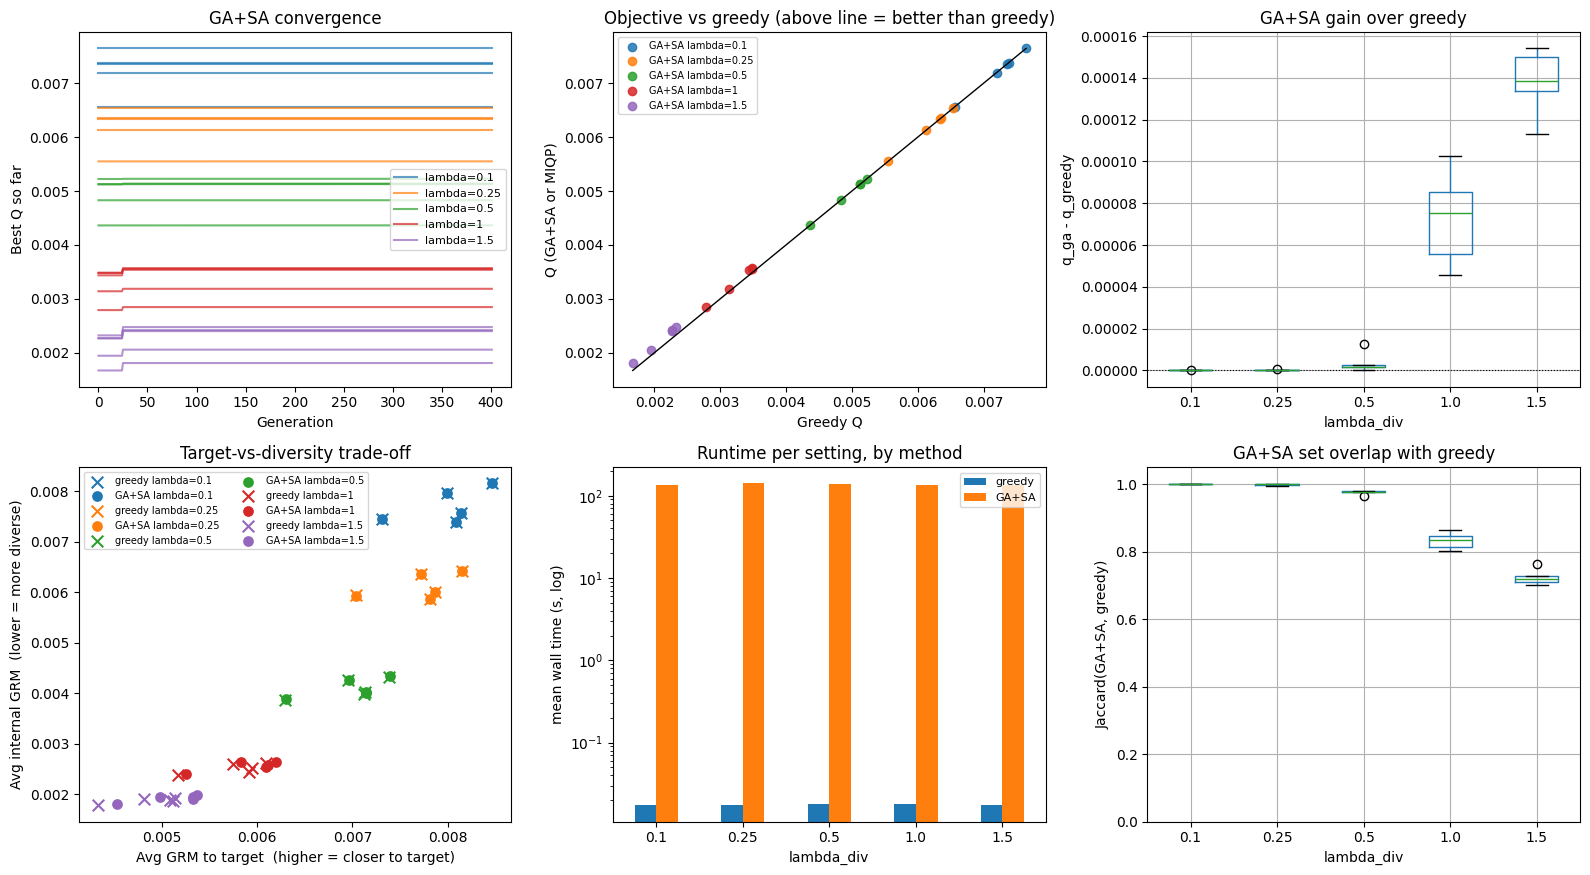

In [15]:
palette = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
lambdas_sorted = sorted(set(LAMBDA_DIVS))
lambda_color = {lam: palette[i % len(palette)] for i, lam in enumerate(lambdas_sorted)}
has_miqp_col = "q_bqp" in ga_results_df.columns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# (0,0) GA+SA convergence ----------------------------------------------------
ax = axes[0, 0]
seen = set()
for item in ga_selected_sets:
    lam = item["lambda_div"]
    ax.plot(item["ga_history"],
            color=lambda_color.get(lam, "gray"),
            alpha=0.7,
            label=f"lambda={lam:g}" if lam not in seen else None)
    seen.add(lam)
ax.set_xlabel("Generation")
ax.set_ylabel("Best Q so far")
ax.set_title("GA+SA convergence")
ax.legend(fontsize=8)

# (0,1) Q comparison (GA, and BQP if available) vs greedy --------------------
ax = axes[0, 1]
for lam, group in ga_results_df.groupby("lambda_div"):
    col = lambda_color.get(lam, "gray")
    ax.scatter(group["q_greedy"], group["q_ga"], color=col, marker="o",
               label=f"GA+SA lambda={lam:g}", alpha=0.85)
    if has_miqp_col:
        ax.scatter(group["q_greedy"], group["q_bqp"], color=col, marker="s",
                   facecolors="none", edgecolors=col,
                   label=f"MIQP lambda={lam:g}", alpha=0.85)
all_q = pd.concat([ga_results_df["q_greedy"], ga_results_df["q_ga"]]
                  + ([ga_results_df["q_bqp"]] if has_miqp_col else []))
lims = [all_q.min(), all_q.max()]
ax.plot(lims, lims, color="black", linewidth=1)
ax.set_xlabel("Greedy Q")
ax.set_ylabel("Q (GA+SA or MIQP)")
ax.set_title("Objective vs greedy (above line = better than greedy)")
ax.legend(fontsize=7)

# (0,2) Gain over greedy by lambda -------------------------------------------
ax = axes[0, 2]
ga_results_df.boxplot(column="q_ga_minus_greedy", by="lambda_div", ax=ax)
ax.axhline(0.0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("lambda_div")
ax.set_ylabel("q_ga - q_greedy")
ax.set_title("GA+SA gain over greedy")
ax.figure.suptitle("")  # boxplot adds an automatic suptitle

# (1,0) Target-vs-diversity trade-off ----------------------------------------
ax = axes[1, 0]
for lam in lambdas_sorted:
    col = lambda_color.get(lam, "gray")
    sub = ga_results_df[ga_results_df["lambda_div"] == lam]
    ax.scatter(sub["avg_target_greedy"], sub["avg_internal_greedy"],
               marker="x", color=col, s=70, linewidths=1.5,
               label=f"greedy lambda={lam:g}")
    ax.scatter(sub["avg_target_ga"], sub["avg_internal_ga"],
               marker="o", color=col, s=45,
               label=f"GA+SA lambda={lam:g}")
ax.set_xlabel("Avg GRM to target  (higher = closer to target)")
ax.set_ylabel("Avg internal GRM  (lower = more diverse)")
ax.set_title("Target-vs-diversity trade-off")
ax.legend(fontsize=7, ncol=2)

# (1,1) Runtime by method (mean per lambda, log scale) -----------------------
ax = axes[1, 1]
time_cols = {"greedy": "greedy_time_sec", "GA+SA": "ga_time_sec"}
if has_miqp_col:
    time_cols["MIQP"] = "miqp_time_sec"
time_df = pd.DataFrame({
    label: ga_results_df.groupby("lambda_div")[col].mean()
    for label, col in time_cols.items()
})
time_df.plot(kind="bar", ax=ax, logy=True)
ax.set_xlabel("lambda_div")
ax.set_ylabel("mean wall time (s, log)")
ax.set_title("Runtime per setting, by method")
ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=8)

# (1,2) Set overlap with greedy ----------------------------------------------
ax = axes[1, 2]
ga_results_df.boxplot(column="ga_jaccard_greedy", by="lambda_div", ax=ax)
ax.set_xlabel("lambda_div")
ax.set_ylabel("Jaccard(GA+SA, greedy)")
ax.set_title("GA+SA set overlap with greedy")
ax.set_ylim(0.0, 1.05)

fig.suptitle("")
fig.tight_layout()
plt.show()